# Customer Segmentation → Marketing Playbook
**Dataset:** UCI Online Retail (download from https://archive.ics.uci.edu/dataset/352/online+retail)

**Project goal:** Segment customers using RFM scoring + K-Means clustering, then translate each segment into a concrete marketing action plan.

**Steps:**
1. Load & clean the data
2. Build RFM features
3. Cluster with K-Means
4. Label and interpret segments
5. Write the marketing playbook

---
**Setup:** Place `Online Retail.xlsx` in the same folder as this notebook.

## 0. Imports & Setup

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load & Clean the Data

In [24]:
# Load the dataset
df = pd.read_excel('Online Retail.xlsx', dtype={'CustomerID': str})
print(f'Raw data shape: {df.shape}')
df.head()

Raw data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [25]:
# Check for nulls and data types
print(df.info())
print('\nNull counts:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB
None

Null counts:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [26]:
# --- Cleaning steps ---

# 1. Drop rows with no CustomerID (can't segment anonymous customers)
df = df.dropna(subset=['CustomerID'])

# 2. Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove rows with zero or negative Quantity or UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 4. Create a revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# 5. Confirm InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f'Clean data shape: {df.shape}')
df.head()

Clean data shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 2. Build RFM Features

**RFM stands for:**
- **Recency** — How recently did the customer buy? (lower = better)
- **Frequency** — How many times did they buy?
- **Monetary** — How much did they spend in total?

In [28]:
# Set the reference date as one day after the last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date.date()}')

# Calculate RFM per customer
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f'\nRFM table shape: {rfm.shape}')
rfm.describe()

Reference date: 2011-12-10

RFM table shape: (4338, 4)


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


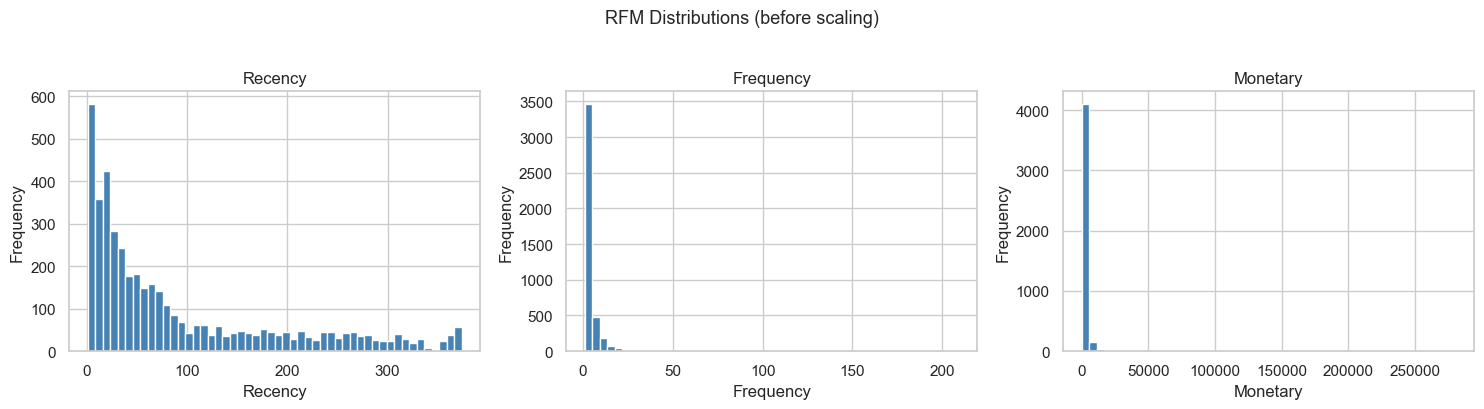

In [29]:
# Visualize the RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    rfm[col].plot(kind='hist', bins=50, ax=ax, title=col, color='steelblue', edgecolor='white')
    ax.set_xlabel(col)

plt.suptitle('RFM Distributions (before scaling)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
# Cap outliers at the 99th percentile to prevent them from distorting clusters
for col in ['Recency', 'Frequency', 'Monetary']:
    cap = rfm[col].quantile(0.99)
    rfm[col] = rfm[col].clip(upper=cap)
    print(f'{col} capped at {cap:.1f}')

Recency capped at 369.0
Frequency capped at 30.0
Monetary capped at 19881.0


In [31]:
# Log-transform Monetary and Frequency to reduce skew, then scale all features
rfm_scaled = rfm.copy()
rfm_scaled['Frequency'] = np.log1p(rfm_scaled['Frequency'])
rfm_scaled['Monetary']  = np.log1p(rfm_scaled['Monetary'])

scaler = StandardScaler()
rfm_scaled[['Recency', 'Frequency', 'Monetary']] = scaler.fit_transform(
    rfm_scaled[['Recency', 'Frequency', 'Monetary']]
)

print('Scaling complete. Preview:')
rfm_scaled[['Recency', 'Frequency', 'Monetary']].describe().round(2)

Scaling complete. Preview:


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-0.92,-0.97,-4.09
25%,-0.75,-0.97,-0.69
50%,-0.42,-0.36,-0.06
75%,0.50,0.68,0.68
max,2.77,3.15,2.70


## 3. K-Means Clustering

We use the **Elbow Method** + **Silhouette Score** to find the right number of clusters.

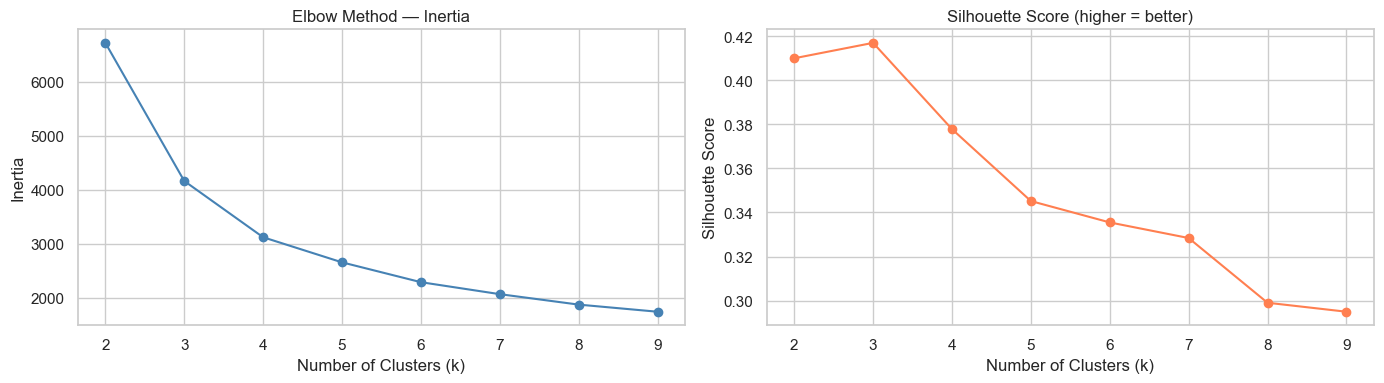


Silhouette scores:
  k=2: 0.410
  k=3: 0.417
  k=4: 0.378
  k=5: 0.345
  k=6: 0.335
  k=7: 0.328
  k=8: 0.299
  k=9: 0.295


In [33]:
X = rfm_scaled[['Recency', 'Frequency', 'Monetary']].values

inertia_scores = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia_scores.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot elbow + silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(k_range, inertia_scores, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='coral')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print('\nSilhouette scores:')
for k, s in zip(k_range, silhouette_scores):
    print(f'  k={k}: {s:.3f}')

In [34]:
# --- Choose k based on the charts above ---
# Typically k=4 or k=5 works well for RFM. Adjust if your charts suggest otherwise.

CHOSEN_K = 4  # <-- change this after reviewing the charts

km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(X)

print(f'Cluster sizes (k={CHOSEN_K}):')
print(rfm['Cluster'].value_counts().sort_index())

Cluster sizes (k=4):
Cluster
0    1325
1    1431
2     930
3     652
Name: count, dtype: int64


## 4. Label & Interpret Segments

In [36]:
# Summarize each cluster by mean RFM values
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_summary['Count'] = rfm.groupby('Cluster')['CustomerID'].count()
cluster_summary['% of Base'] = (cluster_summary['Count'] / len(rfm) * 100).round(1)

print('Cluster Summary:')
cluster_summary

Cluster Summary:


,Recency,Frequency,Monetary,Count,% of Base
Cluster,,,,,
0,58.7,1.5,368.9,1325,30.5
1,47.7,4.0,1543.1,1431,33.0
2,260.2,1.4,406.9,930,21.4
3,20.3,13.0,5919.1,652,15.0


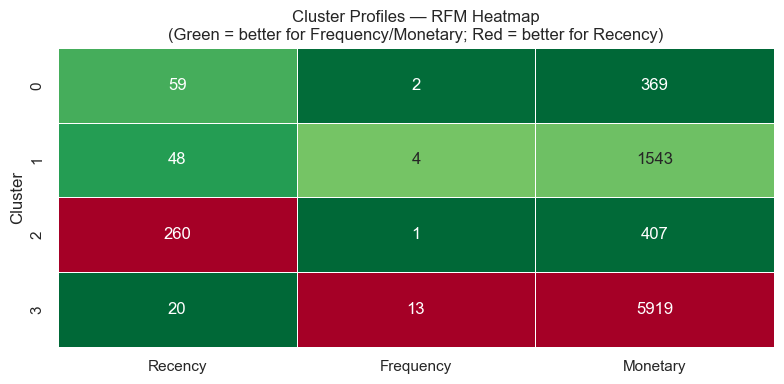

In [37]:
# Visualize cluster profiles as a heatmap (normalized for comparison)
cluster_norm = cluster_summary[['Recency', 'Frequency', 'Monetary']].copy()
cluster_norm = (cluster_norm - cluster_norm.min()) / (cluster_norm.max() - cluster_norm.min())

plt.figure(figsize=(8, 4))
sns.heatmap(cluster_norm, annot=cluster_summary[['Recency', 'Frequency', 'Monetary']],
            fmt='.0f', cmap='RdYlGn_r', linewidths=0.5, cbar=False)
plt.title('Cluster Profiles — RFM Heatmap\n(Green = better for Frequency/Monetary; Red = better for Recency)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [57]:
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean())

            Recency  Frequency     Monetary
Cluster                                    
0         58.744151   1.482264   368.927450
1         47.661076   3.953878  1543.078393
2        260.198925   1.365591   406.868157
3         20.312883  13.033742  5919.113049


In [59]:
# The mathematically correct mapping for your specific clustering run:
segment_map = {
    3: 'Champions / VIPs',
    1: 'Loyal / Promising',
    0: 'At-Risk / Lapsed',
    2: 'Hibernating / Lost'
}

# Apply the mapping to your cluster column
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Print the final counts to check the distribution
print('Final segment counts:')
print(rfm['Segment'].value_counts())

Final segment counts:
Segment
Loyal / Promising     1431
At-Risk / Lapsed      1325
Hibernating / Lost     930
Champions / VIPs       652
Name: count, dtype: int64


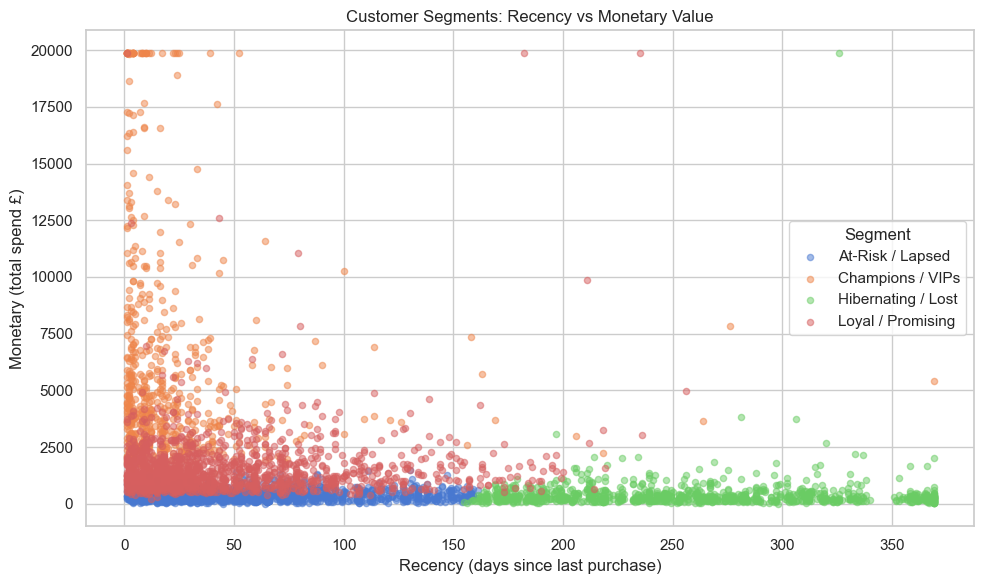

In [61]:
# Scatter plot: Recency vs Monetary, colored by segment
plt.figure(figsize=(10, 6))
for seg, group in rfm.groupby('Segment'):
    plt.scatter(group['Recency'], group['Monetary'], label=seg, alpha=0.5, s=20)

plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spend £)')
plt.title('Customer Segments: Recency vs Monetary Value')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

## 5. Marketing Playbook

 Each segment below gets a specific strategy.

---

### 🏆 Champions
**Who they are:** Bought recently, buy often, spend the most.  
**Goal:** Reward loyalty, activate as brand advocates.  
**Tactics:**
- Early access to new products / launches
- VIP loyalty tier or exclusive rewards
- Referral program — these customers will convert their network
- Solicit reviews and UGC

---

### ⚠️ At-Risk / Lapsed
**Who they are:** Were good customers but haven't purchased in a while.  
**Goal:** Win them back before they're gone for good.  
**Tactics:**
- Win-back email sequence: "We miss you" + time-limited offer
- Show them what's new since their last purchase (dynamic product feed)
- Survey: Why did you stop? (Insight + re-engagement in one)
- Paid retargeting if email engagement drops

---

### 🌱 Promising / New
**Who they are:** Recent first-time or early buyers with growth potential.  
**Goal:** Convert into repeat buyers fast — the first 90 days are critical.  
**Tactics:**
- Onboarding email series focused on product education
- Second-purchase incentive (small discount or free shipping threshold)
- Cross-sell based on first purchase category
- Social proof: reviews, bestsellers in their category

---

### 💤 Hibernating
**Who they are:** Haven't bought in a long time, low frequency, low spend.  
**Goal:** Either reactivate cheaply or suppress from paid campaigns to protect ROAS.  
**Tactics:**
- One last aggressive win-back attempt (deep discount or bundle)
- If no response: move to suppression list for paid ads
- Low-cost email only — don't waste paid budget here
- Consider a sunset flow: unsubscribe the truly gone ones to protect deliverability

---

> **Note:** Adjust segment names and tactics above to match your actual cluster labels.

In [41]:
# Export the segmented customer list (useful for CRM upload or further analysis)
output = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']]
output.to_csv('customer_segments_output.csv', index=False)
print(f'Exported {len(output)} customers to customer_segments_output.csv')
output.head(10)

Exported 4338 customers to customer_segments_output.csv


,CustomerID,Recency,Frequency,Monetary,Segment
0,12346,326,1,19880.9957,Hibernating
1,12347,2,7,4310.0000,At-Risk / Lapsed
2,12348,75,4,1797.2400,Loyal Customers
3,12349,19,1,1757.5500,Loyal Customers
4,12350,310,1,334.4000,Hibernating
5,12352,36,8,2506.0400,At-Risk / Lapsed
6,12353,204,1,89.0000,Hibernating
7,12354,232,1,1079.4000,Hibernating
8,12355,214,1,459.4000,Hibernating
9,12356,23,3,2811.4300,Loyal Customers
